In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 120})

SEED = 42
COLORS = {"2019-2021": "#2C7BB6", "2022-2024": "#D7191C"}

print("Imports OK")

Imports OK


# H3 — Stabilité à court terme des IPO (rendements à 30 jours)

## Hypothèse testée
La performance à 30 jours des IPO de la cohorte **2022-2024** est **plus stable et moins volatile** que celle de la cohorte **2019-2021**.

## Ce que « volatilité » signifie ici
La **volatilité cross-sectionnelle** mesure la dispersion des rendements à 30 jours *entre* les différentes IPOs d'une même cohorte :

$$\sigma_{cohorte} = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(r_i - \bar{r})^2}$$

où $r_i$ est le rendement à 30 jours de l'IPO $i$ et $\bar{r}$ est la moyenne de la cohorte.

> **Interprétation** : une cohorte *plus stable* présente un $\sigma$ *plus faible* → les IPOs ont des performances plus homogènes entre elles.

## Protocole statistique

### Statistiques descriptives
- Moyenne, médiane, écart-type (σ), Q1, Q3, IQR par cohorte
- Coefficient de variation (σ/|μ|) pour comparer la dispersion relative

### Intervalles de confiance à 95% (bootstrap percentile)
- Sur l'**écart-type** : 10 000 ré-échantillons avec remise
- Sur la **médiane** : idem

### Tests statistiques (H1 unilatérale : σ₂₂₋₂₄ < σ₁₉₋₂₁)
| Test | Robustesse | Hypothèse nulle |
|---|---|---|
| **F-test (ratio de variances)** | suppose normalité | σ²₂₂₋₂₄ = σ²₁₉₋₂₁ |
| **Levene (centre=médiane)** | robuste aux outliers | σ₂₂₋₂₄ = σ₁₉₋₂₁ |
| **Fligner-Killeen** | non-paramétrique | σ₂₂₋₂₄ = σ₁₉₋₂₁ |
| **Mann-Whitney** | non-paramétrique | distributions identiques |

> Pour les tests bilatéraux (Levene, Fligner), on convertit en **p unilatéral** :
> - Si σ₂₂₋₂₄ < σ₁₉₋₂₁ → p_unilat = p_bilat / 2
> - Sinon → p_unilat = 1 − p_bilat / 2

## Source de données
- `data/dataset_complet_filled.xlsx` — colonne `ret_30d`

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (12, 5), "figure.dpi": 120})

SEED   = 42
rng    = np.random.default_rng(SEED)
COLORS = {"2019-2021": "#2C7BB6", "2022-2024": "#D7191C"}
N_BOOT = 10_000
ALPHA  = 0.05

print("Imports OK")

Imports OK


In [3]:
# ── Chargement et préparation ───────────────────────────────────────────────
df = pd.read_excel("data/dataset.xlsx")

required = ["year", "ret_30d"]
missing  = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes : {missing}")

df = df[df["year"].between(2019, 2024)].copy()
df["cohort"] = np.where(df["year"].between(2019, 2021), "2019-2021", "2022-2024")

if "ipo_size_m" in df.columns:
    df = df[(df["ipo_size_m"].isna()) |
            (pd.to_numeric(df["ipo_size_m"], errors="coerce") >= 50)].copy()

df["ret_30d"] = pd.to_numeric(df["ret_30d"], errors="coerce")
df = df.dropna(subset=["ret_30d"]).copy()

r_19_21 = df.loc[df["cohort"] == "2019-2021", "ret_30d"].to_numpy()
r_22_24 = df.loc[df["cohort"] == "2022-2024", "ret_30d"].to_numpy()

print(f"IPOs 2019-2021 : {len(r_19_21)}")
print(f"IPOs 2022-2024 : {len(r_22_24)}")

IPOs 2019-2021 : 194
IPOs 2022-2024 : 65


In [4]:
# ── Statistiques descriptives ───────────────────────────────────────────────
def describe_cohort(x, label):
    return {
        "Cohorte":      label,
        "N":            len(x),
        "Moyenne (%)": np.mean(x) * 100,
        "Médiane (%)": np.median(x) * 100,
        "σ (écart-type)": np.std(x, ddof=1),
        "σ (%)": np.std(x, ddof=1) * 100,
        "CV (σ/|μ|)": np.std(x, ddof=1) / abs(np.mean(x)) if np.mean(x) != 0 else np.nan,
        "IQR (%)": (np.percentile(x, 75) - np.percentile(x, 25)) * 100,
        "Q1 (%)": np.percentile(x, 25) * 100,
        "Q3 (%)": np.percentile(x, 75) * 100,
        "Min (%)": np.min(x) * 100,
        "Max (%)": np.max(x) * 100,
    }

desc = pd.DataFrame([
    describe_cohort(r_19_21, "2019-2021"),
    describe_cohort(r_22_24, "2022-2024"),
])

display(desc.style.format({
    "Moyenne (%)":    "{:+.2f}%",
    "Médiane (%)":   "{:+.2f}%",
    "σ (écart-type)": "{:.4f}",
    "σ (%)":          "{:.2f}%",
    "CV (σ/|μ|)":    "{:.2f}",
    "IQR (%)":        "{:.2f}%",
    "Q1 (%)":         "{:+.2f}%",
    "Q3 (%)":         "{:+.2f}%",
    "Min (%)":        "{:+.2f}%",
    "Max (%)":        "{:+.2f}%",
}))

print(f"\nRatio des écarts-types (σ₂₂₋₂₄ / σ₁₉₋₂₁) = "
      f"{np.std(r_22_24, ddof=1)/np.std(r_19_21, ddof=1):.4f}")
print("→ < 1.0 : 2022-2024 plus stable | > 1.0 : 2022-2024 plus volatile")

,Cohorte,N,Moyenne (%),Médiane (%),σ (écart-type),σ (%),CV (σ/|μ|),IQR (%),Q1 (%),Q3 (%),Min (%),Max (%)
0,2019-2021,194,+6.31%,+1.52%,0.2846,28.46%,4.51,27.80%,-9.80%,+18.00%,-51.99%,+130.39%
1,2022-2024,65,+2.61%,+5.37%,0.1837,18.37%,7.05,21.18%,-8.57%,+12.62%,-64.64%,+46.00%



Ratio des écarts-types (σ₂₂₋₂₄ / σ₁₉₋₂₁) = 0.6454
→ < 1.0 : 2022-2024 plus stable | > 1.0 : 2022-2024 plus volatile


In [5]:
# ── Intervalles de confiance bootstrap ─────────────────────────────────────
def bootstrap_ci(x, stat_fn, n_boot=N_BOOT, alpha=ALPHA, seed=SEED):
    """Bootstrap percentile CI pour un estimateur stat_fn appliqué à x."""
    x   = np.asarray(x, dtype=float)
    x   = x[~np.isnan(x)]
    gen = np.random.default_rng(seed)
    idx = gen.integers(0, len(x), size=(n_boot, len(x)))
    boot = np.array([stat_fn(x[i]) for i in idx])
    est  = stat_fn(x)
    lo   = np.quantile(boot, alpha / 2)
    hi   = np.quantile(boot, 1 - alpha / 2)
    return est, lo, hi

std_fn = lambda x: np.std(x, ddof=1)
med_fn = np.median

std_19, std_19_lo, std_19_hi = bootstrap_ci(r_19_21, std_fn, seed=SEED)
std_22, std_22_lo, std_22_hi = bootstrap_ci(r_22_24, std_fn, seed=SEED + 1)

med_19, med_19_lo, med_19_hi = bootstrap_ci(r_19_21, med_fn, seed=SEED + 2)
med_22, med_22_lo, med_22_hi = bootstrap_ci(r_22_24, med_fn, seed=SEED + 3)

ci_table = pd.DataFrame({
    "Indicateur": ["Écart-type σ", "Médiane"],
    "2019-2021":  [f"{std_19*100:.2f}%  [{std_19_lo*100:.2f}% ; {std_19_hi*100:.2f}%]",
                   f"{med_19*100:+.2f}% [{med_19_lo*100:+.2f}% ; {med_19_hi*100:+.2f}%]"],
    "2022-2024":  [f"{std_22*100:.2f}%  [{std_22_lo*100:.2f}% ; {std_22_hi*100:.2f}%]",
                   f"{med_22*100:+.2f}% [{med_22_lo*100:+.2f}% ; {med_22_hi*100:+.2f}%]"],
})

print("=== IC 95% Bootstrap (10 000 ré-échantillons) ===")
display(ci_table)

# Chevauchement des IC sur σ ?
overlap = std_22_lo < std_19_hi and std_19_lo < std_22_hi
print(f"\nLes IC sur σ se chevauchent : {'OUI → différence non significative à 95%' if overlap else 'NON → différence significative'}")

=== IC 95% Bootstrap (10 000 ré-échantillons) ===


,Indicateur,2019-2021,2022-2024
0,Écart-type σ,28.46% [24.12% ; 32.83%],18.37% [13.95% ; 22.74%]
1,Médiane,+1.52% [-0.67% ; +3.77%],+5.37% [+0.28% ; +9.04%]



Les IC sur σ se chevauchent : NON → différence significative


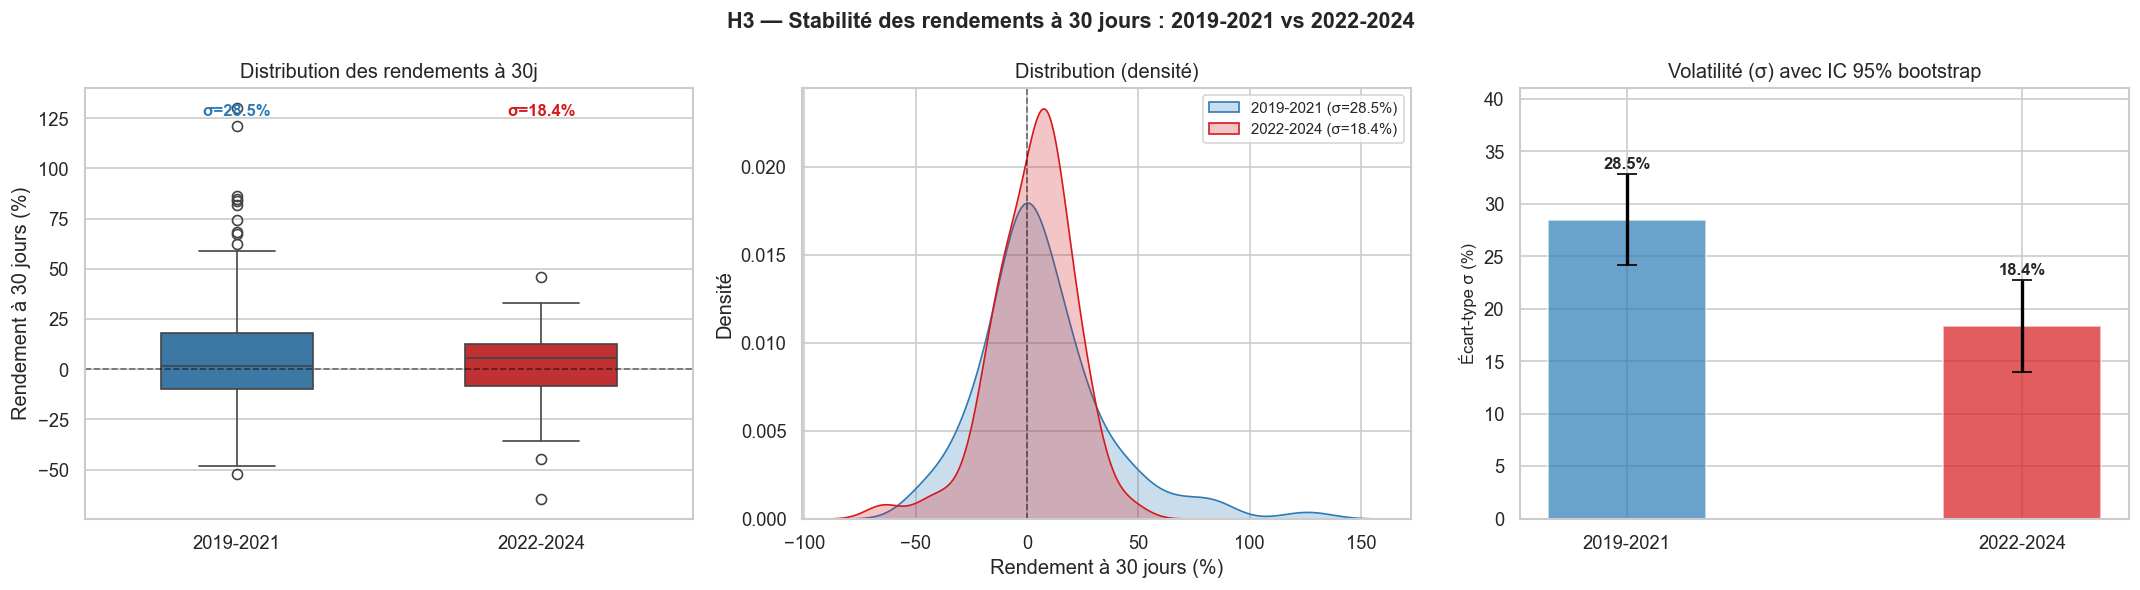

In [6]:
# ── Visualisations ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Boxplot
ax = axes[0]
plot_df = df[["cohort", "ret_30d"]].copy()
plot_df["ret_30d"] *= 100
sns.boxplot(
    data=plot_df, x="cohort", y="ret_30d",
    order=["2019-2021", "2022-2024"],
    palette=[COLORS["2019-2021"], COLORS["2022-2024"]],
    ax=ax, width=0.5,
)
ax.axhline(0, color="black", lw=1, ls="--", alpha=0.5)
ax.set_xlabel("")
ax.set_ylabel("Rendement à 30 jours (%)")
ax.set_title("Distribution des rendements à 30j")
for cohort, std_val in [("2019-2021", std_19), ("2022-2024", std_22)]:
    idx = ["2019-2021", "2022-2024"].index(cohort)
    ax.text(idx, ax.get_ylim()[1] * 0.90,
            f"σ={std_val*100:.1f}%",
            ha="center", fontsize=10, fontweight="bold",
            color=COLORS[cohort])

# 2. KDE
ax = axes[1]
for cohort, r in [("2019-2021", r_19_21), ("2022-2024", r_22_24)]:
    sns.kdeplot(r * 100, ax=ax, fill=True, alpha=0.25,
                color=COLORS[cohort], label=f"{cohort} (σ={np.std(r, ddof=1)*100:.1f}%)")
ax.axvline(0, color="black", lw=1, ls="--", alpha=0.5)
ax.set_xlabel("Rendement à 30 jours (%)")
ax.set_ylabel("Densité")
ax.set_title("Distribution (densité)")
ax.legend(fontsize=9)

# 3. Bootstrap des σ avec IC
ax = axes[2]
cohorts_lbl = ["2019-2021", "2022-2024"]
stds   = [std_19 * 100, std_22 * 100]
lo_s   = [std_19_lo * 100, std_22_lo * 100]
hi_s   = [std_19_hi * 100, std_22_hi * 100]
cols   = [COLORS[c] for c in cohorts_lbl]

bars = ax.bar(cohorts_lbl, stds, color=cols, alpha=0.7, width=0.4)
for i, (lo, hi, std) in enumerate(zip(lo_s, hi_s, stds)):
    ax.errorbar(i, std, yerr=[[std - lo], [hi - std]],
                fmt="none", color="black", capsize=6, lw=2)
    ax.text(i, hi + 0.5, f"{std:.1f}%", ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("Écart-type σ (%)", fontsize=10)
ax.set_title("Volatilité (σ) avec IC 95% bootstrap")
ax.set_ylim(0, max(hi_s) * 1.25)

fig.suptitle("H3 — Stabilité des rendements à 30 jours : 2019-2021 vs 2022-2024",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [7]:
# ── Tests statistiques sur les variances ───────────────────────────────────
# H0 : σ²(2022-2024) = σ²(2019-2021)
# H1 : σ²(2022-2024) < σ²(2019-2021)  [unilatéral]

direction_ok = std_22 < std_19  # True si 2022-2024 plus stable

# 1. F-test (ratio des variances)
var_ratio = np.var(r_22_24, ddof=1) / np.var(r_19_21, ddof=1)
df1_f, df2_f = len(r_22_24) - 1, len(r_19_21) - 1
# P(F ≤ ratio) sous H0 → test unilatéral gauche (H1: ratio < 1)
p_ftest = stats.f.cdf(var_ratio, df1_f, df2_f)

# 2. Levene (robuste, centré sur médiane) → bilatéral → unilatéral
lev_stat, p_lev_bi = stats.levene(r_19_21, r_22_24, center="median")
p_lev = p_lev_bi / 2 if direction_ok else 1 - p_lev_bi / 2

# 3. Fligner-Killeen (non-paramétrique) → bilatéral → unilatéral
fli_stat, p_fli_bi = stats.fligner(r_19_21, r_22_24)
p_fli = p_fli_bi / 2 if direction_ok else 1 - p_fli_bi / 2

# 4. Mann-Whitney (test directionnel sur les rendements)
# H1 : 2022-2024 a des rendements plus faibles (moins exubérants) → alternative='less'
mw_stat, p_mw = stats.mannwhitneyu(r_22_24, r_19_21, alternative="two-sided")

results = pd.DataFrame({
    "Test": [
        "F-test (ratio variances, unilatéral)",
        "Levene (médiane, unilatéral)",
        "Fligner-Killeen (unilatéral)",
        "Mann-Whitney U (bilatéral, complémentaire)",
    ],
    "Hypothèse testée": [
        "σ²₂₂₋₂₄ < σ²₁₉₋₂₁",
        "σ₂₂₋₂₄ < σ₁₉₋₂₁",
        "σ₂₂₋₂₄ < σ₁₉₋₂₁",
        "distributions identiques",
    ],
    "Statistique": [var_ratio, lev_stat, fli_stat, mw_stat],
    "p-value":     [p_ftest,   p_lev,    p_fli,    p_mw],
    "Significatif à 5%": [
        p_ftest < ALPHA, p_lev < ALPHA, p_fli < ALPHA, p_mw < ALPHA
    ],
})

display(results.style.format({"Statistique": "{:.4f}", "p-value": "{:.4f}"}))

print(f"""
Informations complémentaires :
  σ(2019-2021) = {std_19*100:.2f}%  IC95=[{std_19_lo*100:.2f}% ; {std_19_hi*100:.2f}%]
  σ(2022-2024) = {std_22*100:.2f}%  IC95=[{std_22_lo*100:.2f}% ; {std_22_hi*100:.2f}%]
  Ratio σ₂₂₋₂₄/σ₁₉₋₂₁ = {var_ratio**0.5:.4f}  
  Direction attendue (σ₂₂₋₂₄ < σ₁₉₋₂₁) : {'✓ OUI' if direction_ok else '✗ NON'}
""")

,Test,Hypothèse testée,Statistique,p-value,Significatif à 5%
0,"F-test (ratio variances, unilatéral)",σ²₂₂₋₂₄ < σ²₁₉₋₂₁,0.4165,0.0000,True
1,"Levene (médiane, unilatéral)",σ₂₂₋₂₄ < σ₁₉₋₂₁,5.3152,0.0110,True
2,Fligner-Killeen (unilatéral),σ₂₂₋₂₄ < σ₁₉₋₂₁,4.6504,0.0155,True
3,"Mann-Whitney U (bilatéral, complémentaire)",distributions identiques,6332.0000,0.9596,False



Informations complémentaires :
  σ(2019-2021) = 28.46%  IC95=[24.12% ; 32.83%]
  σ(2022-2024) = 18.37%  IC95=[13.95% ; 22.74%]
  Ratio σ₂₂₋₂₄/σ₁₉₋₂₁ = 0.6454  
  Direction attendue (σ₂₂₋₂₄ < σ₁₉₋₂₁) : ✓ OUI



In [8]:
# ── Tableau de synthèse final ───────────────────────────────────────────────
any_sig = p_ftest < ALPHA or p_lev < ALPHA or p_fli < ALPHA

if direction_ok and any_sig:
    conclusion = "CONFIRMÉE"
    explication = "σ₂₂₋₂₄ < σ₁₉₋₂₁ ET au moins un test de variance significatif."
elif direction_ok and not any_sig:
    conclusion = "PARTIELLEMENT CONFIRMÉE"
    explication = "σ₂₂₋₂₄ < σ₁₉₋₂₁ mais aucun test n'est significatif (p > 5%)."
else:
    conclusion = "NON CONFIRMÉE"
    explication = "σ₂₂₋₂₄ ≥ σ₁₉₋₂₁ : 2022-2024 n'est pas plus stable que 2019-2021."

summary = pd.DataFrame({
    "Indicateur": [
        "σ (écart-type ret_30d)",
        "IC95 σ",
        "IQR",
        "Ratio σ₂₂₋₂₄ / σ₁₉₋₂₁",
        "p-value F-test (unilatéral)",
        "p-value Levene (unilatéral)",
        "p-value Fligner (unilatéral)",
        "p-value Mann-Whitney (bilatéral)",
    ],
    "2019-2021": [
        f"{std_19*100:.2f}%",
        f"[{std_19_lo*100:.2f}% ; {std_19_hi*100:.2f}%]",
        f"{(np.percentile(r_19_21,75)-np.percentile(r_19_21,25))*100:.2f}%",
        "", "", "", "", ""
    ],
    "2022-2024": [
        f"{std_22*100:.2f}%",
        f"[{std_22_lo*100:.2f}% ; {std_22_hi*100:.2f}%]",
        f"{(np.percentile(r_22_24,75)-np.percentile(r_22_24,25))*100:.2f}%",
        "", "", "", "", ""
    ],
    "Valeur test": [
        "", "", "",
        f"{var_ratio**0.5:.4f}",
        f"{p_ftest:.4f}",
        f"{p_lev:.4f}",
        f"{p_fli:.4f}",
        f"{p_mw:.4f}",
    ],
})

display(summary)

print(f"""
{'='*60}
=== DÉCISION H3 : {conclusion} ===
{'='*60}
{explication}

Lecture :
  - Un ratio σ < 1.0 indique que 2022-2024 est plus stable.
  - Si p < 0.05 sur les tests de variance → différence significative.
  - Mann-Whitney teste si les distributions sont différentes
    (position + forme), et non uniquement la variance.
{'='*60}
""")

,Indicateur,2019-2021,2022-2024,Valeur test
0,σ (écart-type ret_30d),28.46%,18.37%,
1,IC95 σ,[24.12% ; 32.83%],[13.95% ; 22.74%],
2,IQR,27.80%,21.18%,
3,Ratio σ₂₂₋₂₄ / σ₁₉₋₂₁,,,0.6454
4,p-value F-test (unilatéral),,,0.0000
5,p-value Levene (unilatéral),,,0.0110
6,p-value Fligner (unilatéral),,,0.0155
7,p-value Mann-Whitney (bilatéral),,,0.9596



=== DÉCISION H3 : CONFIRMÉE ===
σ₂₂₋₂₄ < σ₁₉₋₂₁ ET au moins un test de variance significatif.

Lecture :
  - Un ratio σ < 1.0 indique que 2022-2024 est plus stable.
  - Si p < 0.05 sur les tests de variance → différence significative.
  - Mann-Whitney teste si les distributions sont différentes
    (position + forme), et non uniquement la variance.



## 📈 Régression OLS
Pour s'assurer que la baisse de la volatilité n'est pas uniquement due à la taille, à la rentabilité ou au secteur des IPOs, nous appliquons une régression OLS avec erreurs standard robustes (HC3).
Le modèle: `ret_30d_dispersion ~ is_post_2021 + log_size + profitable + C(sector)`
Note: Nous modélisons l'écart absolu à la médiane de la cohorte comme proxy individuel de la dispersion (volatilité).

In [9]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Preparation des données pour OLS
df_ols = df.dropna(subset=['ret_30d', 'ipo_size_m', 'sector']).copy()
df_ols['is_post_2021'] = (df_ols['year'] >= 2022).astype(int)
df_ols['log_size'] = np.log1p(pd.to_numeric(df_ols['ipo_size_m'], errors='coerce'))
df_ols['profitable'] = df_ols['profitable'].fillna(0).astype(int)

# Calculer la médiane du rendement par cohorte pour avoir l'écart absolu
median_19 = df_ols.loc[df_ols['is_post_2021'] == 0, 'ret_30d'].median()
median_22 = df_ols.loc[df_ols['is_post_2021'] == 1, 'ret_30d'].median()

df_ols['ret_30d_dispersion'] = np.where(
    df_ols['is_post_2021'] == 0, 
    np.abs(df_ols['ret_30d'] - median_19), 
    np.abs(df_ols['ret_30d'] - median_22)
)

model = smf.ols("ret_30d_dispersion ~ is_post_2021 + log_size + profitable + C(sector)", data=df_ols).fit(cov_type='HC3')
print(model.summary())
print("\n=> Si le coefficient de is_post_2021 est négatif et significatif, la période taux élevés réduit la volatilité toutes choses égales par ailleurs.")


                            OLS Regression Results                            
Dep. Variable:     ret_30d_dispersion   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.417
Date:                Wed, 29 Apr 2026   Prob (F-statistic):              0.190
Time:                        23:18:42   Log-Likelihood:                 62.958
No. Observations:                 259   AIC:                            -107.9
Df Residuals:                     250   BIC:                            -75.90
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

## 🔁 Analyse de Biais (Robustesse sans l'année 2021)
L'année 2021 a été une année de bulle extrême. Pour vérifier que nos résultats ne dépendent pas uniquement de cette année, nous retirons 2021 et re-testons l'écart-type et la significativité.

In [10]:
# Filtrer pour exclure 2021
df_robust = df[df['year'] != 2021].copy()

r_19_20 = df_robust.loc[df_robust["cohort"] == "2019-2021", "ret_30d"].to_numpy()
r_22_24 = df_robust.loc[df_robust["cohort"] == "2022-2024", "ret_30d"].to_numpy()

r_19_20 = r_19_20[~np.isnan(r_19_20)]
r_22_24 = r_22_24[~np.isnan(r_22_24)]

std_19_20 = np.std(r_19_20, ddof=1)
std_22_24 = np.std(r_22_24, ddof=1)

stat_lev_rob, p_lev_rob = stats.levene(r_22_24, r_19_20, center='median')
p_lev_rob_uni = p_lev_rob / 2 if std_22_24 < std_19_20 else 1 - p_lev_rob / 2

print("=== Test de Robustesse (sans 2021) ===")
print(f"σ (2019-2020) : {std_19_20*100:.2f}% (N={len(r_19_20)})")
print(f"σ (2022-2024) : {std_22_24*100:.2f}% (N={len(r_22_24)})")
print(f"Ratio σ : {std_22_24 / std_19_20:.4f}")
print(f"p-value Levene (unilatéral) : {p_lev_rob_uni:.4f}")

if std_22_24 < std_19_20 and p_lev_rob_uni < 0.05:
    print("\n=> Robustesse validée : La cohorte taux élevés reste significativement moins volatile même sans l'année 2021.")
else:
    print("\n=> Robustesse non validée : L'effet disparaît si on enlève 2021.")


=== Test de Robustesse (sans 2021) ===
σ (2019-2020) : 27.96% (N=120)
σ (2022-2024) : 18.37% (N=65)
Ratio σ : 0.6570
p-value Levene (unilatéral) : 0.0177

=> Robustesse validée : La cohorte taux élevés reste significativement moins volatile même sans l'année 2021.
